In [1]:
# ubermag for dataprocessing
import micromagneticdata as mdata
# plotting
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import numpy as np

In [2]:
# getting the driver
drive_eq    = mdata.Data(name="nanopillar_relax_05", dirname='../../data/simulations/')[0]
drive_pulse = mdata.Data(name="nanopillar_dynamics_05", dirname='../../data/simulations/')[0]
drive_evo   = mdata.Data(name="nanopillar_dynamics_05", dirname='../../data/simulations/')[-1]

In [3]:
# parameters
Ms = 0.86e6 # saturation of magnetisation (A/m)
save_dt = 0.5e-12 # time spacing
t_max = 100e-12 # max time that we want
n_steps = int(t_max/save_dt) # quantity of points
t_pulse = 1e-12
n_pulse = int(t_pulse/save_dt)

# getting the array of the field at t=0
# drive[i] where i is the time step we want
# shape: (nx, ny, nz, 3) where nx is the cell and the 3 contains the m_i (0=mx, 1=my, 2=mz)
arr0 = drive_evo[0].array
nx, ny, nz, _ = arr0.shape

# getting the middle points
iy = ny//2
iz = nz//2

# getting the equilibrium magnetisation (normalized)
m0_y = drive_eq[0].array[:, iy, iz, 1]/Ms

# create array for magnetisation
dm_y = np.zeros((n_steps+n_pulse, nx))
# loop to save the data for the stage 1 (pulse on)
for i in range(n_pulse):
    m_y = drive_pulse[i].array[:, iy, iz, 1]/Ms # gettin my(x, y0, z0) at t=i (normalized)
    # subtract the equlibrium magnetisation
    dm_y[i] = m_y - m0_y
# loop to save the data for the stage 2 (pulse off)
for i in range(n_steps):
    m_y = drive_evo[i].array[:, iy, iz, 1]/Ms # gettin my(x, y0, z0) at t=i (normalized)
    # subtract the equlibrium magnetisation
    dm_y[i+n_pulse] = m_y - m0_y

# create the mesh for the surface map
times = np.arange(n_steps)*save_dt*1e12
x = drive_evo.to_xarray().x.values*1e9

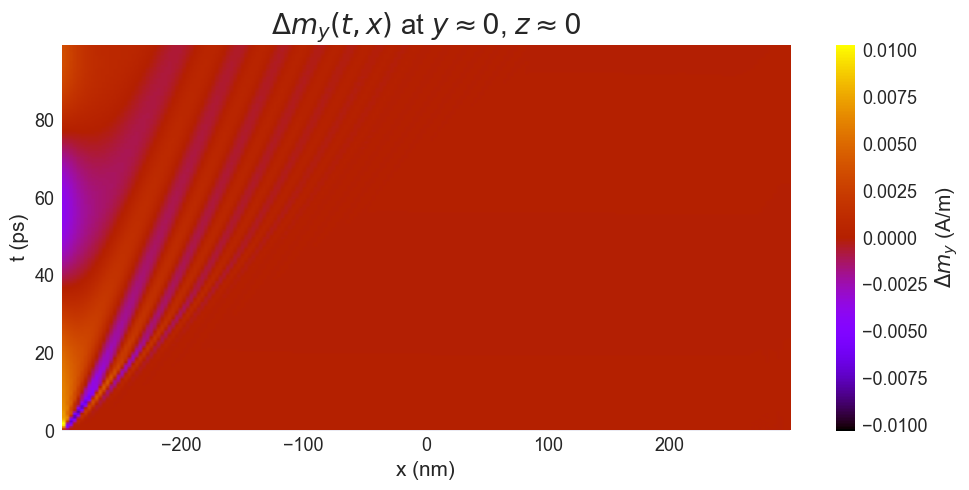

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
extent = [x[0], x[-1], times[0], times[-1]]
vmax = np.abs(dm_y).max()
im = ax.imshow(dm_y, aspect='auto', origin='lower', extent=extent,
               cmap='gnuplot', vmin=-vmax, vmax=vmax)
ax.set_xlabel('x (nm)')
ax.set_ylabel('t (ps)')
ax.set_title(r'$\Delta m_y(t, x)$ at $y \approx 0$, $z \approx 0$')
plt.colorbar(im, ax=ax, label=r'$\Delta m_y$ (A/m)')
plt.tight_layout()
plt.show()

In [5]:
# Hanning window for less leakage at boundaries
win_t = np.hanning(n_steps+n_pulse)[:, np.newaxis]
win_x = np.hanning(nx)[np.newaxis, :]
dm_y_w = dm_y * win_t * win_x

# apply the 2D-FFT
fft2d = np.fft.fftshift(np.fft.fft2(dm_y_w[:, ::-1]))
fft_mag = np.abs(fft2d) / ((n_steps+n_pulse) * nx)

# frequency axis
dt = save_dt
dx = drive_eq[0].mesh.cell[0]*1e9
# apply fft for the axis
omega_GHz = np.fft.fftshift(np.fft.fftfreq(n_steps+n_pulse, d=dt))*1e-9  # GHz
k_per_nm  = np.fft.fftshift(np.fft.fftfreq(nx, d=dx))*2*np.pi        # 1/nm

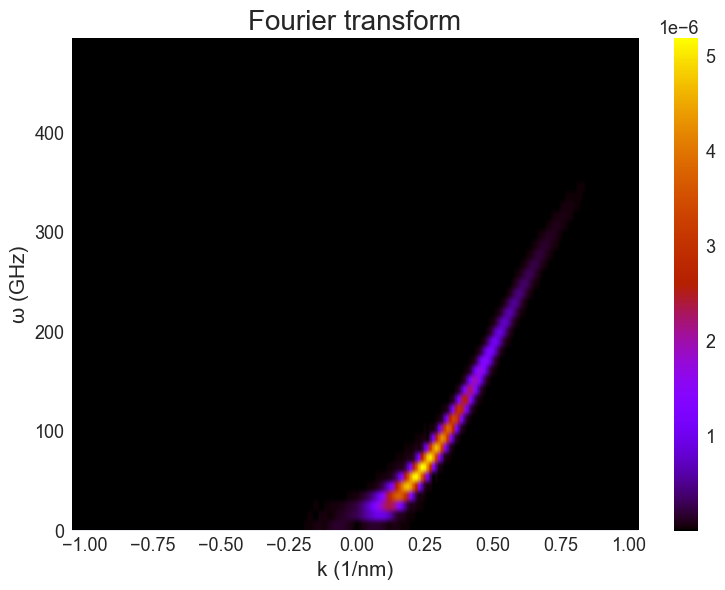

In [7]:
# --- Plot positive frequencies only ---
pos    = (omega_GHz >= 0) & (omega_GHz <= 500)
extent = [k_per_nm[0], k_per_nm[-1], omega_GHz[pos][0], omega_GHz[pos][-1]]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(fft_mag[pos, :], aspect='auto', origin='lower',
               extent=extent, cmap='gnuplot')
ax.set_xlabel('k (1/nm)')
ax.set_ylabel('ω (GHz)')
ax.set_title('Fourier transform')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()